# Intermediate Activation Values of Real Model

查看一个Transformer模型在推理过程的真实激活值$P$

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import inspect
import transformers.models.gpt2.modeling_gpt2 as modeling_gpt2
from transformers.models import GPT2LMHeadModel

BLOCK_SIZE_COL = 4
BLOCK_SIZE_ROW = 4 # Flash Attention的分块大小
#* S & P的维度应该是：[batch_size, num_heads, query_length, key_length]

d:\Anaconda\conda_envs\general\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class AttentionStatsCollector:
    """
    A simple class to collect attention statistics, layer level.
    """
    def __init__(self, layer_idx):
        self.layer_idx = layer_idx

        self.P = []
        self.P_unnormalized = []

    def update(self, P: torch.Tensor, P_unnormalized: torch.Tensor):
        """
        Args:
            P: shape: (N, )，应当已经剔除mask值且flattened
            P_unnormalized: shape: (N, )，应当已经剔除mask值且flattened
        """
        self.P.append(P.detach().cpu())
        self.P_unnormalized.append(P_unnormalized.detach().cpu())

    def concat(self):
        """把list拼成一个大tensor"""
        P = torch.cat(self.P, dim=0)
        P_unnorm = torch.cat(self.P_unnormalized, dim=0)
        return P, P_unnorm
    
class FlashAttentionStatsCollector:
    def __init__(self, layer_idx):
        self.layer_idx = layer_idx
        self.blocks = []

    def update_block(self, row_start_idx, col_start_idx, block_data: torch.Tensor):
        """
        Args:
            row_start_idx (int): 当前 Block 在全局 Query 序列中的起始行号 (i)
            col_start_idx (int): 当前 Block 在全局 Key 序列中的起始列号 (j)
            block_data (Tensor): 该块内的 exp(Score - Max) 数据 (Flattened & CPU)
        """
        self.blocks.append({
            "r": row_start_idx,
            "c": col_start_idx,
            "data": block_data.detach().cpu() # 立即转存 CPU 防止爆显存
        })

    def get_block_stats_df(self):
        """(可选) 辅助函数，将来用于把数据转成 DataFrame 方便分析"""
        import pandas as pd
        stats = []
        for b in self.blocks:
            data = b["data"].float()
            if data.numel() == 0: continue
            stats.append({
                "layer": self.layer_idx,
                "r": b["r"],
                "c": b["c"],
                "max": data.max().item(),
                "min": data.min().item(), 
                "mean": data.mean().item(),
                "std": data.std().item() if data.numel() > 1 else 0
            })
        return pd.DataFrame(stats)

In [3]:

#* 修改原有的Attention前向传播函数，以便输出中间变量
def eager_attention_forward_customized(module, query, key, value, attention_mask, head_mask=None, **kwargs):
    # print("custom eager attention called.")
    # print(f"Query shape: {query.shape}")
    attn_weights = torch.matmul(query, key.transpose(-1, -2))

    if module.scale_attn_weights:
        attn_weights = attn_weights / torch.full(
            [], value.size(-1) ** 0.5, dtype=attn_weights.dtype, device=attn_weights.device
        )

    # Layer-wise attention scaling
    if module.scale_attn_by_inverse_layer_idx:
        attn_weights = attn_weights / float(module.layer_idx + 1)

    # 先准备一个“有效位置 mask”，用于后面采样 P / P_unnormalized
    query_length, key_length = query.size(-2), key.size(-2)

    valid_mask = torch.ones_like(attn_weights, dtype=torch.bool)

    if not module.is_cross_attention:
        # if only "normal" attention layer implements causal mask
        query_length, key_length = query.size(-2), key.size(-2)
        causal_mask = module.bias[:, :, key_length - query_length : key_length, :key_length]
        mask_value = torch.finfo(attn_weights.dtype).min
        # Need to be a tensor, otherwise we get error: `RuntimeError: expected scalar type float but found double`.
        # Need to be on the same device, otherwise `RuntimeError: ..., x and y to be on the same device`
        mask_value = torch.full([], mask_value, dtype=attn_weights.dtype, device=attn_weights.device)
        attn_weights = torch.where(causal_mask, attn_weights.to(attn_weights.dtype), mask_value)

        valid_mask = causal_mask.expand_as(attn_weights)
    else:
        valid_mask = torch.ones_like(attn_weights, dtype=torch.bool)

    if attention_mask is not None:
        am = attention_mask[:, :, :, :key_length]
        if am.dtype == torch.bool:
            attn_mask_valid = am
        else:
            # HF 常见：有效位置为 0，无效位置为 -1e4 / -inf（两者都覆盖）
            attn_mask_valid = (am == 0) | torch.isposinf(-am)  # 兼容 -inf 的一种写法（可选）
            # 更保守也可只用 (am == 0)

        if attn_mask_valid.shape != attn_weights.shape:
            attn_mask_valid = attn_mask_valid.expand_as(attn_weights)

        valid_mask = valid_mask & attn_mask_valid
        # Apply the attention mask（原逻辑保留）
        attn_weights = attn_weights + am

    #* attn_weights = nn.functional.softmax(attn_weights, dim=-1)
    #* 我们把这里的Softmax拆开以便看到中间结果
    #* Shape of attn_weights: (batch_size, num_heads, query_length, key_length)
    scores = attn_weights
    # 行最大值
    max_scores = torch.max(dim=-1, input=scores, keepdim=True).values # 负数维度表示“倒数第几个”，我们要在最后一个维度即key_length方向上取最大值
    # 未归一化的P
    attn_exp = torch.exp(scores - max_scores)
    # 归一化因子
    attn_sum = attn_exp.sum(dim=-1, keepdim=True)
    # 归一化后的P
    attn_weights = attn_exp / attn_sum
    #* 统计相关量
    P = attn_weights.detach()[valid_mask]           #! Shape: (batch_size, num_heads, query_length, key_length)
    P_unnormalized = attn_exp.detach()[valid_mask]
    #* 保存相关量
    collector = globals().get("COLLECTORS", {}).get(int(module.layer_idx), None)
    if collector is not None:
        collector.update(P, P_unnormalized)

    # Downcast (if necessary) back to V's dtype (if in mixed-precision) -- No-Op otherwise
    attn_weights = attn_weights.type(value.dtype)
    attn_weights = module.attn_dropout(attn_weights)

    # Mask heads if we want to
    if head_mask is not None:
        attn_weights = attn_weights * head_mask

    attn_output = torch.matmul(attn_weights, value)
    attn_output = attn_output.transpose(1, 2)

    #* Simulate Flash Attention Forward
    flash_collector = globals().get("COLLECTORS_FLASH", {}).get(int(module.layer_idx), None)
    if flash_collector is not None:
        # Outer loop
        for i in range(0, query_length, BLOCK_SIZE_ROW):
            q_tile = query[:, :, i:i+BLOCK_SIZE_ROW, :]  # (batch_size, num_heads, BLOCK_SIZE_ROW, head_dim)
            # print(f"q_tile shape: {q_tile.shape}")
            # 分块都是沿seq_length维度分
            m = torch.full((BLOCK_SIZE_ROW, ), float('-inf'))
            l = torch.zeros((BLOCK_SIZE_ROW, ))
            o = torch.zeros_like(q_tile)

            # Inner loop
            for j in range(0, key_length, BLOCK_SIZE_COL):
                k_tile = key[:, :, j:j+BLOCK_SIZE_COL, :]  # (batch_size, num_heads, BLOCK_SIZE_COL, head_dim)

                s_tile = torch.matmul(q_tile, k_tile.transpose(-1, -2))
                s_tile = s_tile / torch.full([], value.size(-1) ** 0.5, dtype=s_tile.dtype, device=s_tile.device)
                
                # Masking part
                row_idx = torch.arange(i, i + q_tile.size(2), device=s_tile.device).view(-1, 1)
                col_idx = torch.arange(j, j + k_tile.size(2), device=s_tile.device).view(1, -1)
                mask = col_idx > row_idx
                s_tile.masked_fill_(mask, float('-inf'))
                
                rowmax = torch.max(input=s_tile, dim=-1).values
                m_new = torch.maximum(m, rowmax)
                exp_s = torch.exp(s_tile - m_new.unsqueeze(-1))
                l = torch.exp(m - m_new) * l + torch.sum(exp_s, dim=-1)
                
                # 统计相关量（分块形式）
                valid_mask = ~mask
                valid_mask = valid_mask.expand_as(exp_s)
                p_tile_data = exp_s[valid_mask]
                flash_collector.update_block(row_start_idx=i, col_start_idx=j, block_data=p_tile_data)
               
    return attn_output, attn_weights

In [4]:
# 用Mokey Patch替换原有的函数
modeling_gpt2.eager_attention_forward = eager_attention_forward_customized
# print(inspect.getsource(modeling_gpt2.eager_attention_forward))
# 实例化GPT2模型
model_gpt2 = GPT2LMHeadModel.from_pretrained('gpt2',
                                             dtype=torch.float32,
                                             attn_implementation="eager")
# 初始化Collector
collectors = {}
collectors_flash = {}

for layer_idx, block in enumerate(model_gpt2.transformer.h):
    # 在 GPT-2 结构里，transformer.h 是一个按层排列的 block 列表（长度等于层数）
    collectors[layer_idx] = AttentionStatsCollector(layer_idx)
    # 每层都有一个collectors对象
    collectors_flash[layer_idx] = FlashAttentionStatsCollector(layer_idx)

# 让 monkey patch 的 forward 能访问到（全局变量）
COLLECTORS = collectors
COLLECTORS_FLASH = collectors_flash

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
inputs = tokenizer("The one who walks alongside flames, shall one day meet the road of destined death.", return_tensors="pt")
# return_tensors="pt" 的含义是“把输出直接转成 PyTorch 张量”

model_gpt2.eval()
with torch.no_grad():
    _ = model_gpt2(**inputs)

# 检查是否收集到了
p0, p0u = collectors[2].concat()
print(p0.numel(), p0.min().item(), p0.max().item())
print(p0u.numel(), p0u.min().item(), p0u.max().item())

layer_2_flash_stats = collectors_flash[2]
print(f"Total blocks collected: {len(layer_2_flash_stats.blocks)}")

if len(layer_2_flash_stats.blocks) > 0:
    first_block = layer_2_flash_stats.blocks[0]
    print(f"Block at (row={first_block['r']}, col={first_block['c']})")
    print(f"Data samples: {first_block['data'].shape}") # 打印前10个数值

samples = layer_2_flash_stats.get_block_stats_df()
samples

1836 2.4954650257313915e-07 1.0
1836 3.0407571216528595e-07 1.0
Total blocks collected: 25
Block at (row=0, col=0)
Data samples: torch.Size([120])


,layer,r,c,max,min,mean,std
0,2,0,0,1.0,0.005782,0.517071,0.427235
1,2,4,0,1.0,0.010979,0.415579,0.392313
2,2,4,4,1.0,0.014621,0.624644,0.356574
3,2,8,0,1.0,0.000082,0.331809,0.408387
4,2,8,4,1.0,0.003939,0.559410,0.355389
5,2,8,8,1.0,0.017755,0.674986,0.338494
6,2,12,0,1.0,0.000018,0.296564,0.414747
7,2,12,4,1.0,0.003102,0.553104,0.355850
8,2,12,8,1.0,0.008863,0.562593,0.348924
9,2,12,12,1.0,0.016145,0.614250,0.373899


In [6]:
import numpy as np
import pandas as pd
import torch

def tensor_basic_stats(x: torch.Tensor, name: str, layer: int):
    # x: 1D CPU tensor
    x = x.float()
    eps = 1e-12
    return {
        "layer": layer,
        "name": name,
        "n": int(x.numel()),
        "min": float(x.min().item()) if x.numel() else np.nan,
        "max": float(x.max().item()) if x.numel() else np.nan,
        "mean": float(x.mean().item()) if x.numel() else np.nan,
        "std": float(x.std(unbiased=False).item()) if x.numel() else np.nan,
        "p50": float(torch.quantile(x, 0.50).item()) if x.numel() else np.nan,
        "p90": float(torch.quantile(x, 0.90).item()) if x.numel() else np.nan,
        "p99": float(torch.quantile(x, 0.99).item()) if x.numel() else np.nan,
        "p999": float(torch.quantile(x, 0.999).item()) if x.numel() else np.nan,
        # 对于长尾分布很有用：log10(x) 的分位数（P 会有很多很小的值）
        "log10_p50": float(torch.quantile(torch.log10(x + eps), 0.50).item()) if x.numel() else np.nan,
        "log10_p99": float(torch.quantile(torch.log10(x + eps), 0.99).item()) if x.numel() else np.nan,
    }

rows = []
layer_ids = sorted(collectors.keys())

for layer in layer_ids:
    P, Pu = collectors[layer].concat()  # 都是 1D CPU tensor（你之前布尔索引隐式 flatten 了）
    rows.append(tensor_basic_stats(P, "P", layer))
    rows.append(tensor_basic_stats(Pu, "P_unnormalized", layer))

df = pd.DataFrame(rows).sort_values(["name", "layer"]).reset_index(drop=True)
df

,layer,name,n,min,max,mean,std,p50,p90,p99,p999,log10_p50,log10_p99
0,0,P,1836,2.200368e-08,1.0,0.111111,0.189619,0.054137,0.234557,0.996838,1.0,-1.266506,-0.001375
1,1,P,1836,2.404000e-04,1.0,0.111111,0.170777,0.057714,0.240990,0.943357,1.0,-1.238722,-0.025328
2,2,P,1836,2.495465e-07,1.0,0.111111,0.180781,0.044043,0.293742,0.966506,1.0,-1.356128,-0.014796
3,3,P,1836,1.232383e-07,1.0,0.111111,0.213775,0.022831,0.374537,0.988431,1.0,-1.641477,-0.005054
4,4,P,1836,1.967291e-26,1.0,0.111111,0.231396,0.018539,0.394859,0.999997,1.0,-1.731909,-0.000001
5,5,P,1836,5.936352e-09,1.0,0.111111,0.252333,0.011128,0.426869,0.999264,1.0,-1.953591,-0.000320
6,6,P,1836,9.657719e-08,1.0,0.111111,0.240431,0.016746,0.412134,0.991526,1.0,-1.776086,-0.003697
7,7,P,1836,1.634179e-06,1.0,0.111111,0.248707,0.015416,0.429470,0.995533,1.0,-1.812025,-0.001944
8,8,P,1836,7.747299e-05,1.0,0.111111,0.240195,0.019062,0.443390,0.976972,1.0,-1.719831,-0.010118
9,9,P,1836,4.933201e-05,1.0,0.111111,0.257416,0.012752,0.524013,0.993059,1.0,-1.894411,-0.003025


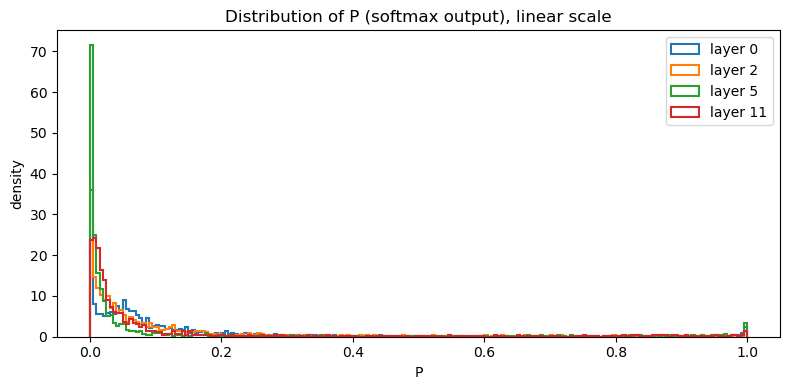

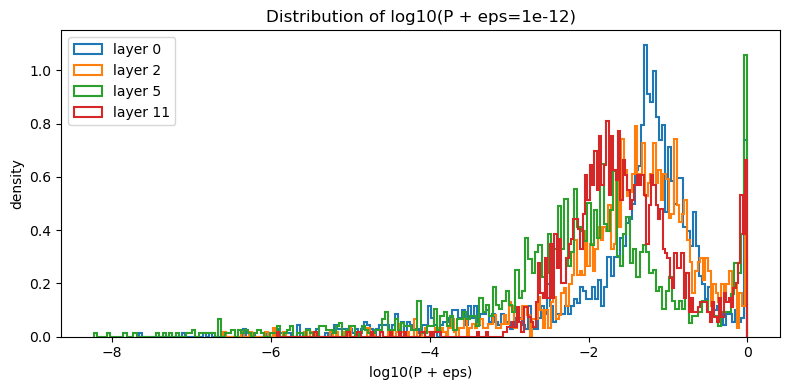

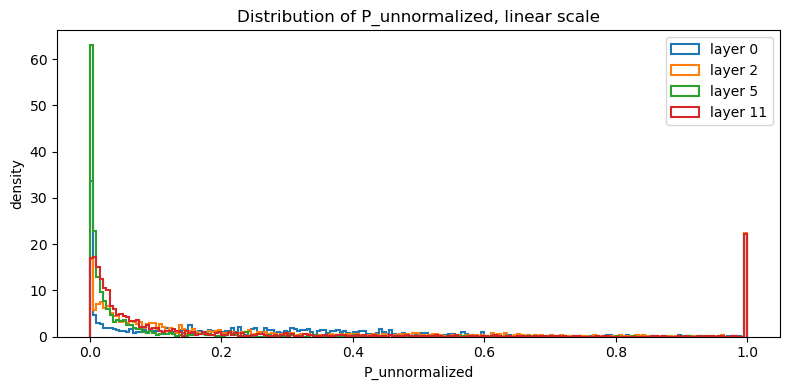

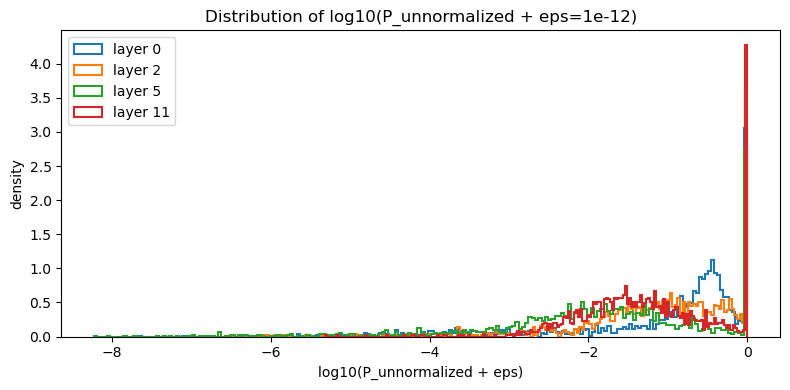

In [7]:
import matplotlib.pyplot as plt

def sample_1d(x: torch.Tensor, max_points=200_000, seed=0):
    # 为了画图快一点，随机采样最多 max_points 个点
    n = x.numel()
    if n <= max_points:
        return x
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)
    idx = torch.randint(0, n, (max_points,), generator=g)
    return x[idx]

layers_to_plot = [0, 2, 5, 11]  # 自己改
bins = 200
eps = 1e-12

# 1) P 的线性直方图（density）
plt.figure(figsize=(8, 4))
for layer in layers_to_plot:
    P, _ = collectors[layer].concat()
    P = sample_1d(P, max_points=200_000, seed=layer).float()
    plt.hist(P.numpy(), bins=bins, density=True, histtype="step", linewidth=1.5, label=f"layer {layer}")
plt.title("Distribution of P (softmax output), linear scale")
plt.xlabel("P")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

# 2) log10(P) 的直方图（更能看清长尾）
plt.figure(figsize=(8, 4))
for layer in layers_to_plot:
    P, _ = collectors[layer].concat()
    P = sample_1d(P, max_points=200_000, seed=layer).float()
    logP = torch.log10(P + eps)
    plt.hist(logP.numpy(), bins=bins, density=True, histtype="step", linewidth=1.5, label=f"layer {layer}")
plt.title(f"Distribution of log10(P + eps={eps})")
plt.xlabel("log10(P + eps)")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

# 1) P_unnormalized 的线性直方图（density）
plt.figure(figsize=(8, 4))
for layer in layers_to_plot:
    _, P_unnormalized = collectors[layer].concat()
    P_unnormalized = sample_1d(P_unnormalized, max_points=200_000, seed=layer).float()
    plt.hist(P_unnormalized.numpy(), bins=bins, density=True, histtype="step", linewidth=1.5, label=f"layer {layer}")
plt.title("Distribution of P_unnormalized, linear scale")
plt.xlabel("P_unnormalized")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

# 2) log10(P_unnormalized) 的直方图（更能看清长尾）
plt.figure(figsize=(8, 4))
for layer in layers_to_plot:
    _, P_unnormalized = collectors[layer].concat()
    P_unnormalized = sample_1d(P_unnormalized, max_points=200_000, seed=layer).float()
    logP = torch.log10(P_unnormalized + eps)
    plt.hist(logP.numpy(), bins=bins, density=True, histtype="step", linewidth=1.5, label=f"layer {layer}")
plt.title(f"Distribution of log10(P_unnormalized + eps={eps})")
plt.xlabel("log10(P_unnormalized + eps)")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

## Intermediate value of FLASH ATTENTION

--- Layer 10 Tile Stats ---
Tile(r=0, c=0): count=120, min=0.0007, max=1.0000, mean=0.4153
Tile(r=4, c=4): count=120, min=0.0472, max=1.0000, mean=0.6331
Tile(r=8, c=8): count=120, min=0.0070, max=1.0000, mean=0.6472
Tile(r=12, c=8): count=192, min=0.0198, max=1.0000, mean=0.5477
Tile(r=16, c=4): count=192, min=0.0734, max=1.0000, mean=0.5451
Tile(r=16, c=16): count=48, min=1.0000, max=1.0000, mean=1.0000


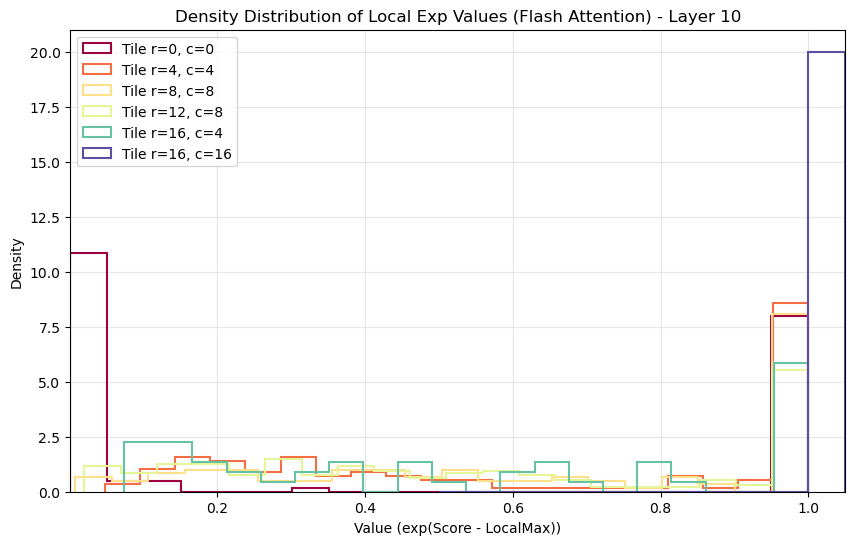

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_flash_tiles_density(flash_collector, layer_idx, num_tiles_to_plot=5):
    """
    可视化 Flash Attention 分块数据的密度分布。
    
    Args:
        flash_collector: FlashAttentionStatsCollector 对象
        layer_idx: 要查看的层号
        num_tiles_to_plot: 想要画多少个块（每个块是由一层中的12个注意力头组成的，因此在掩码之后一共还有120个数据）
    """
    stats = flash_collector[layer_idx]
    blocks = stats.blocks
    
    if len(blocks) == 0:
        print(f"Layer {layer_idx} has no collected blocks.")
        return

    # 筛选出非空的块（防止只有mask的块混入）
    valid_blocks = [b for b in blocks if b['data'].numel() > 0]
    
    # 简单的采样策略：取开头、中间、结尾的几个块，尽量覆盖不同位置
    # 或者直接取前N个
    total_valid = len(valid_blocks)
    indices = np.linspace(0, total_valid - 1, num_tiles_to_plot, dtype=int)
    # indices = range(min(num_tiles_to_plot, total_valid)) # 如果只想看前几个用这行
    
    plt.figure(figsize=(10, 6))
    
    # 颜色映射
    colors = plt.get_cmap('Spectral')(np.linspace(0, 1, num_tiles_to_plot))
    
    max_val_found = float('-inf')
    min_val_found = float('inf')

    print(f"--- Layer {layer_idx} Tile Stats ---")
    
    for idx, color in zip(indices, colors):
        block = valid_blocks[idx]
        data = block['data'].float().numpy()
        
        r, c = block['r'], block['c']
        
        # 打印一些统计信息方便你对照
        print(f"Tile(r={r}, c={c}): count={len(data)}, min={data.min():.4f}, max={data.max():.4f}, mean={data.mean():.4f}")
        
        max_val_found = max(max_val_found, data.max())
        min_val_found = min(min_val_found, data.min())
        
        # 绘制密度图 (density=True)
        plt.hist(data, bins=20, density=True, 
                 histtype="step", linewidth=1.5,
                 label=f"Tile r={r}, c={c}",
                 color=color)

    plt.title(f"Density Distribution of Local Exp Values (Flash Attention) - Layer {layer_idx}")
    plt.xlabel("Value (exp(Score - LocalMax))")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 既然是 exp(S - Max)，理论最大值是 exp(0)=1。我们把X轴限制一下让图好看点
    # 通常这些值集中在 0 到 1 之间
    plt.xlim(max(0, min_val_found), min(1.05, max_val_found * 1.1))
    
    plt.show()

# --- 使用示例 ---
# 假设你已经跑完了推理，并且 COLLECTORS_FLASH 已经填充了数据
# 查看第 2 层的数据
visualize_flash_tiles_density(COLLECTORS_FLASH, layer_idx=10, num_tiles_to_plot=6)

--- Layer 2 Sampling 6 Tiles ---
Tile 1: Global Pos(r=0, c=0) | Elements=120 | Mean=0.5171
Tile 2: Global Pos(r=4, c=4) | Elements=120 | Mean=0.6246
Tile 3: Global Pos(r=8, c=8) | Elements=120 | Mean=0.6750
Tile 4: Global Pos(r=12, c=8) | Elements=192 | Mean=0.5626
Tile 5: Global Pos(r=16, c=4) | Elements=192 | Mean=0.5182
Tile 6: Global Pos(r=16, c=16) | Elements=48 | Mean=1.0000


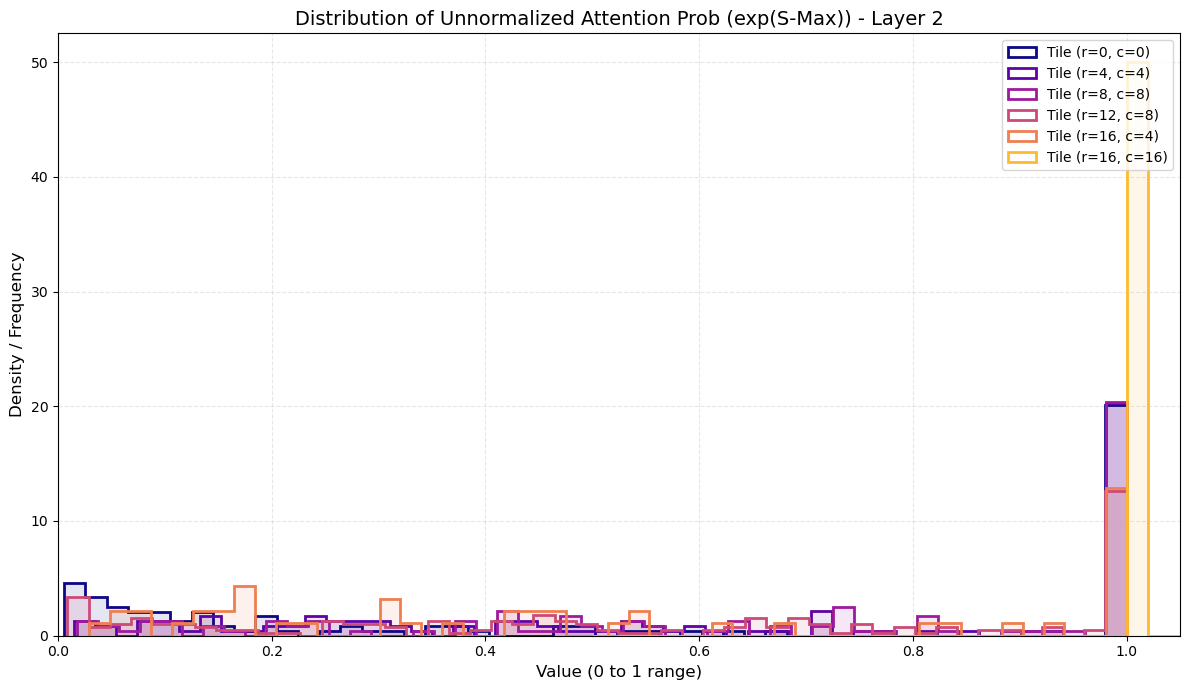

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_flash_tiles_linear(flash_collector, layer_idx, num_tiles=6):
    """
    可视化 Flash Attention 分块数据的线性分布直方图。
    
    Args:
        flash_collector: 你的收集器对象
        layer_idx: 层号
        num_tiles: 要画几个块
    """
    stats = flash_collector[layer_idx]
    blocks = stats.blocks
    
    # 1. 过滤掉数据量太少的空块
    valid_blocks = [b for b in blocks if b['data'].numel() > 5]
    total_valid = len(valid_blocks)
    
    if total_valid == 0:
        print("No valid blocks found.")
        return

    # 2. 均匀采样 N 个块 (比如取头、尾和中间的)
    indices = np.linspace(0, total_valid - 1, num_tiles, dtype=int)
    # 或者如果你只想看有代表性的前几个：
    # indices = range(min(num_tiles, total_valid))
    
    plt.figure(figsize=(12, 7))
    
    # 使用 viridis 颜色映射
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 0.85, num_tiles)) # 0.85避免取到最亮黄看不清

    print(f"--- Layer {layer_idx} Sampling {len(indices)} Tiles ---")

    for i, idx in enumerate(indices):
        block = valid_blocks[idx]
        data = block['data'].float().numpy()
        r, c = block['r'], block['c']
        
        # 打印信息验证
        print(f"Tile {i+1}: Global Pos(r={r}, c={c}) | Elements={len(data)} | Mean={data.mean():.4f}")

        # 3. 绘图
        # density=True 表示纵轴是概率密度（频率）
        # alpha 设置透明度以便重叠时能看到
        # bins 设置稍多一点以看清分布细节
        plt.hist(data, bins=50, density=True, 
                 histtype='step', linewidth=2, 
                 color=colors[i],
                 label=f"Tile (r={r}, c={c})")
        
        # 也可以加上半透明填充，看个人喜好
        plt.hist(data, bins=50, density=True, 
                 histtype='stepfilled', alpha=0.1, 
                 color=colors[i])

    plt.title(f"Distribution of Unnormalized Attention Prob (exp(S-Max)) - Layer {layer_idx}", fontsize=14)
    plt.xlabel("Value (0 to 1 range)", fontsize=12)
    plt.ylabel("Density / Frequency", fontsize=12)
    plt.legend(loc='upper right')
    
    # X轴范围通常是 exp(-inf) ~ exp(0)，即 0 到 1
    # 但由于可能有头部极值，我们聚焦在 0 ~ 1.05
    plt.xlim(0, 1.05)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# --- 执行可视化 ---
# 假设你在第2层
if 2 in COLLECTORS_FLASH:
    visualize_flash_tiles_linear(COLLECTORS_FLASH, layer_idx=2, num_tiles=6)
else:
    print("Layer 2 data not found.")